<a href="https://colab.research.google.com/github/sreehariar04/netflix-analysis/blob/main/exit_test_sreehari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EXIT TEST**

In [85]:
pip install openpyxl

In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

**LOAD DATA**

In [87]:
# Load all sheets from the Excel file
excel_file = '/content/partpdf_1772778998739_partpdf_1763620928546_netflix_titles (1).xlsx'

# Load all sheets
netflix_titles = pd.read_excel(excel_file, sheet_name='netflix_titles')
netflix_titles_cast = pd.read_excel(excel_file, sheet_name='netflix_titles_cast')
netflix_titles_directors = pd.read_excel(excel_file, sheet_name='netflix_titles_directors')
netflix_titles_countries = pd.read_excel(excel_file, sheet_name='netflix_titles_countries')
netflix_titles_category = pd.read_excel(excel_file,sheet_name = 'netflix_titles_category')

print(f"netflix_titles shape: {netflix_titles.shape}")
print(f"netflix_titles_cast shape: {netflix_titles_cast.shape}")
print(f"netflix_titles_directors shape: {netflix_titles_directors.shape}")
print(f"netflix_titles_countries shape: {netflix_titles_countries.shape}")
print(f"netflix_titles_category shape: {netflix_titles_category.shape}")


netflix_titles shape: (6236, 9)
netflix_titles_cast shape: (44311, 2)
netflix_titles_directors shape: (4852, 2)
netflix_titles_countries shape: (7179, 2)
netflix_titles_category shape: (13670, 2)


In [88]:
# Step 2: Aggregate multi-valued columns before merging
cast_agg = netflix_titles_cast.groupby('show_id')['cast'].apply(
    lambda x: ', '.join(x.dropna().astype(str).unique())
).reset_index()
cast_agg.columns = ['show_id', 'cast_agg']

directors_agg = netflix_titles_directors.groupby('show_id')['director'].apply(
    lambda x: ', '.join(x.dropna().astype(str).unique())
).reset_index()
directors_agg.columns = ['show_id', 'director_agg']

countries_agg = netflix_titles_countries.groupby('show_id')['country'].apply(
    lambda x: ', '.join(x.dropna().astype(str).unique())
).reset_index()
countries_agg.columns = ['show_id', 'country_agg']

category_agg = netflix_titles_category.groupby('show_id')['listed_in'].apply(
    lambda x: ', '.join(x.dropna().astype(str).unique())
).reset_index()
category_agg.columns = ['show_id', 'category_agg']

In [89]:
# Using LEFT JOIN to preserve all titles from main table
merged_df = netflix_titles.copy()

# Merge with cast information
merged_df = merged_df.merge(
    cast_agg,
    on='show_id',
    how='left'
)

# Merge with directors
merged_df = merged_df.merge(
    directors_agg,
    on='show_id',
    how='left'
)

# Merge with countries
merged_df = merged_df.merge(
    countries_agg,
    on='show_id',
    how='left'
)

# Merge with category
merged_df = merged_df.merge(
    category_agg,
    on='show_id',
    how='left'
)


In [90]:
merged_df = merged_df.drop(columns=['cast', 'director', 'country', 'listed_in'], errors='ignore')
merged_df = merged_df.rename(columns={
    'cast_agg': 'cast',
    'director_agg': 'director',
    'country_agg': 'country',
    'category_agg': 'listed_in'
})

### Join used : **LEFT JOIN**

1. Preserve All Primary Data
- The netflix_titles sheet is the master dataset containing all Netflix shows with their core attributes (title, description, release_year, etc.)
- Using a LEFT JOIN ensures that ALL titles from the main table are retained, even if some have missing supplementary information
- This is crucial for data integrity i don't want to lose any rows just because it's missing cast, director, or genre data.

2. Handle Missing Data
- Not all shows may have complete information in every supplementary sheet
- For example, a title might not have director information, or cast data might be incomplete
- A LEFT JOIN introduces NULL values for missing relationships, which is preferable to losing entire records

**LEFT JOIN is the optimal choice because it preserves analytical integrity, maintains complete coverage of our primary dataset, and  handles missing information in supplementary sources.**

##Primary Data Analysis

In [91]:
merged_df.head()

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,cast,director,country,listed_in
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,"Alan Marriott, Jennifer Cameron, Lee Tockar, J...","Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies"
1,94,NaN,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0,Jandino Asporaat,NaN,United Kingdom,Stand-Up Comedy
2,NaN,1,TV Show,Transformers Prime,2018-09-08 00:00:00,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0,"Peter Cullen, Kevin Michael Richardson, Josh K...",NaN,United States,Kids' TV
3,NaN,1,TV Show,Transformers: Robots in Disguise,2018-09-08 00:00:00,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0,"Will Friedle, Mitchell Whitfield, Ted McGinley...",NaN,United States,Kids' TV
4,99,NaN,Movie,#realityhigh,2017-09-08 00:00:00,2017.0,TV-14,When nerdy high schooler Dani finally attracts...,80125979.0,"Nesta Cooper, Alicia Sanz, Kid Ink, Jake Borel...",Fernando Lebrija,United States,Comedies


In [92]:
merged_df.shape

(6236, 13)

In [93]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6236 entries, 0 to 6235
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration_minutes  4267 non-null   object 
 1   duration_seasons  1971 non-null   object 
 2   type              6235 non-null   object 
 3   title             6235 non-null   object 
 4   date_added        6223 non-null   object 
 5   release_year      6234 non-null   float64
 6   rating            6223 non-null   object 
 7   description       6233 non-null   object 
 8   show_id           6232 non-null   float64
 9   cast              5663 non-null   object 
 10  director          4263 non-null   object 
 11  country           5756 non-null   object 
 12  listed_in         6232 non-null   object 
dtypes: float64(2), object(11)
memory usage: 633.5+ KB


#Data Cleaning and PreProcessing

In [94]:
merged_df.isnull().sum()

,0
duration_minutes,1969
duration_seasons,4265
type,1
title,1
date_added,13
release_year,2
rating,13
description,3
show_id,4
cast,573


In [95]:
# Convert date_added to datetime format with explicit format
merged_df['date_added'] = pd.to_datetime(merged_df['date_added'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# For missing dates, use release_year to create approximate date
missing_date_mask = merged_df['date_added'].isnull()

# Only fill if release_year is available (not NaN)
release_year_available = merged_df.loc[missing_date_mask, 'release_year'].notna()

# Create the date string first
date_strings = (merged_df.loc[missing_date_mask & release_year_available, 'release_year']
                .astype(int)
                .astype(str) + '-01-01')

# Then convert with explicit format
merged_df.loc[missing_date_mask & release_year_available, 'date_added'] = pd.to_datetime(
    date_strings,
    format='%Y-%m-%d',
    errors='coerce'
)
# For rows where both date_added AND release_year are missing, use a default date
still_missing = merged_df['date_added'].isnull()
merged_df.loc[still_missing, 'date_added'] = pd.to_datetime('1970-01-01', format='%Y-%m-%d')

In [96]:
#Extract year_added and month_added for trend analysis
merged_df['year_added'] = merged_df['date_added'].dt.year
merged_df['month_added'] = merged_df['date_added'].dt.month

In [97]:
#Handle Missing Title
merged_df['title'] = merged_df['title'].fillna('Unknown Title')


In [98]:
#Handle missing release_year
median_year = merged_df['release_year'].median()
merged_df['release_year'] = merged_df['release_year'].fillna(median_year)

In [99]:
# Generate unique IDs for missing show_ids
if merged_df['show_id'].isnull().sum() > 0:
    max_id = merged_df['show_id'].max()
    missing_indices = merged_df[merged_df['show_id'].isnull()].index
    for i, idx in enumerate(missing_indices):
        merged_df.loc[idx, 'show_id'] = max_id + i + 1

#Handle missing listed_in
merged_df['listed_in'] = merged_df['listed_in'].fillna('Not Categorized')

In [100]:
# Handle missing values in director
merged_df['director'] = merged_df['director'].fillna('Not Available')

In [101]:
#Handle missing values in country
merged_df['country'] = merged_df['country'].fillna('Not Available')

In [102]:
# Handle missing values in cast
merged_df['cast'] = merged_df['cast'].fillna('Not Available')

In [103]:
#Handle missing values in rating
merged_df['rating'] = merged_df['rating'].fillna('Not Rated')

In [104]:
#Handle missing values in description
merged_df['description'] = merged_df['description'].fillna('No description available')

In [105]:
#Handle missing values in type
merged_df['type'] = merged_df['type'].fillna('Not Specified')

In [106]:
#Handle missing values in duration columns

# For duration_minutes
merged_df['duration_minutes'] = merged_df['duration_minutes'].fillna(0)

# For duration_seasons
merged_df['duration_seasons'] = merged_df['duration_seasons'].fillna(0)

In [107]:
print(f"\nDataFrame Shape: {merged_df.shape}")

print(merged_df.isnull().sum())

numeric_cols = merged_df.select_dtypes(['int64', 'float64']).columns.tolist()
categorical_cols = merged_df.select_dtypes(['object']).columns.tolist()

data = merged_df.copy()


DataFrame Shape: (6236, 15)
duration_minutes    0
duration_seasons    0
type                0
title               0
date_added          0
release_year        0
rating              0
description         0
show_id             0
cast                0
director            0
country             0
listed_in           0
year_added          0
month_added         0
dtype: int64


For handling the missing country data , i used a placeholder 'Not Available'. I used this strategy due to the importance of country in which the movie is released, rather than removing it using a placeholder was a better choice

In [108]:
data.shape

(6236, 15)

In [109]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6236 entries, 0 to 6235
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   duration_minutes  6236 non-null   object        
 1   duration_seasons  6236 non-null   object        
 2   type              6236 non-null   object        
 3   title             6236 non-null   object        
 4   date_added        6236 non-null   datetime64[ns]
 5   release_year      6236 non-null   float64       
 6   rating            6236 non-null   object        
 7   description       6236 non-null   object        
 8   show_id           6236 non-null   float64       
 9   cast              6236 non-null   object        
 10  director          6236 non-null   object        
 11  country           6236 non-null   object        
 12  listed_in         6236 non-null   object        
 13  year_added        6236 non-null   int32         
 14  month_added       6236 n

In [110]:
data.head()

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,cast,director,country,listed_in,year_added,month_added
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,"Alan Marriott, Jennifer Cameron, Lee Tockar, J...","Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
1,94,0,Movie,Jandino: Whatever it Takes,2016-09-09,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0,Jandino Asporaat,Not Available,United Kingdom,Stand-Up Comedy,2016,9
2,0,1,TV Show,Transformers Prime,2018-09-08,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0,"Peter Cullen, Kevin Michael Richardson, Josh K...",Not Available,United States,Kids' TV,2018,9
3,0,1,TV Show,Transformers: Robots in Disguise,2018-09-08,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0,"Will Friedle, Mitchell Whitfield, Ted McGinley...",Not Available,United States,Kids' TV,2018,9
4,99,0,Movie,#realityhigh,2017-09-08,2017.0,TV-14,When nerdy high schooler Dani finally attracts...,80125979.0,"Nesta Cooper, Alicia Sanz, Kid Ink, Jake Borel...",Fernando Lebrija,United States,Comedies,2017,9


# Advanced Transformation


In [116]:
# Create a copy for transformation
data_exploded = data.copy()

# EXPLODE THE CAST COLUMN
data_exploded['cast'] = data_exploded['cast'].str.split(', ')
data_exploded_cast = data_exploded.explode('cast')

data_exploded_cast['cast'].head(20)

data_exploded_cast.info()

data_exploded_cast.head(15)



<class 'pandas.core.frame.DataFrame'>
Index: 44873 entries, 0 to 6235
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   duration_minutes  44873 non-null  object        
 1   duration_seasons  44873 non-null  object        
 2   type              44873 non-null  object        
 3   title             44873 non-null  object        
 4   date_added        44873 non-null  datetime64[ns]
 5   release_year      44873 non-null  float64       
 6   rating            44873 non-null  object        
 7   description       44873 non-null  object        
 8   show_id           44873 non-null  float64       
 9   cast              44873 non-null  object        
 10  director          44873 non-null  object        
 11  country           44873 non-null  object        
 12  listed_in         44873 non-null  object        
 13  year_added        44873 non-null  int32         
 14  month_added       44873 non-

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,cast,director,country,listed_in,year_added,month_added
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Alan Marriott,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Jennifer Cameron,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Lee Tockar,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Jonathan Holmes,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Michael Dobson,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Andrew Toth,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Brian Dobson,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Cole Howard,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Lisa Durupt,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,Maya Kay,"Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9


#EDA

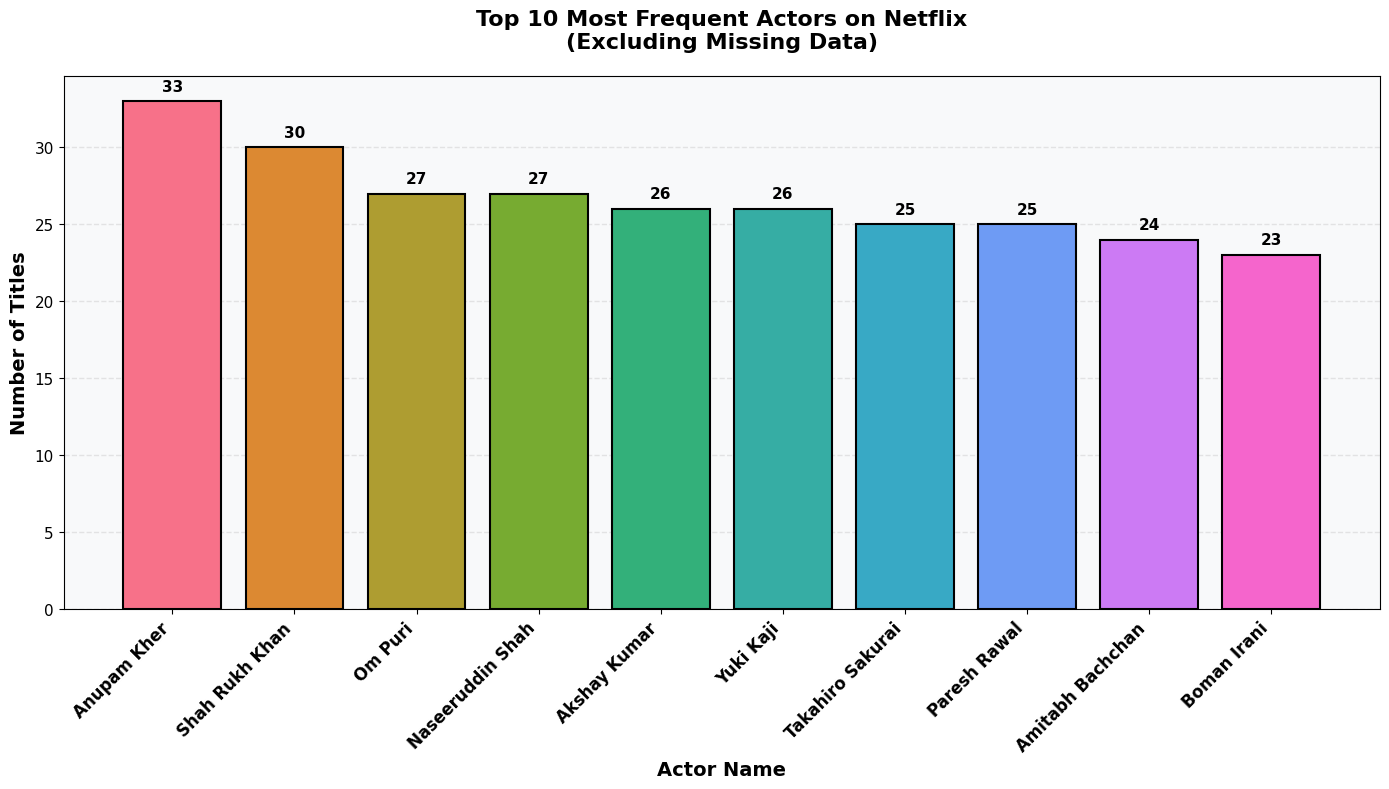

In [117]:
# Get top 10 most frequent actors (excluding 'Not Available')
top_10_actors_raw = data_exploded_cast['cast'].value_counts().head(10)


# Remove 'Not Available' and get actual top 10 actors
top_10_actors = data_exploded_cast[data_exploded_cast['cast'] != 'Not Available']['cast'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(14, 8))

colors = sns.color_palette("husl", 10)
bars = ax.bar(range(len(top_10_actors)), top_10_actors.values, color=colors, edgecolor='black', linewidth=1.5)

ax.set_xlabel('Actor Name', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Titles', fontsize=14, fontweight='bold')
ax.set_title('Top 10 Most Frequent Actors on Netflix\n(Excluding Missing Data)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(range(len(top_10_actors)))
ax.set_xticklabels(top_10_actors.index, rotation=45, ha='right', fontsize=12, fontweight='bold')
ax.tick_params(axis='y', labelsize=11)

# Add value labels on top of each bar
for i, (actor, count) in enumerate(top_10_actors.items()):
    ax.text(i, count + 0.5, str(int(count)), ha='center', va='bottom', fontweight='bold', fontsize=11)


ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=1)
ax.set_axisbelow(True)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()



The analysis shows Indian actors lead the chart with most number of titles also with two japanese actors, this shows that Indian film industry produces movies more than any other industries also the target audience (indians) are contributing a lot to the view time.

In [119]:
# Save the cleaned dataframe to CSV
output_file = 'netflix_cleaned.csv'

data.to_csv(output_file, index=False)


In [121]:
df = pd.read_csv('/content/netflix_cleaned.csv')
df.head()

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,cast,director,country,listed_in,year_added,month_added
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,"Alan Marriott, Jennifer Cameron, Lee Tockar, J...","Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019,9
1,94,0,Movie,Jandino: Whatever it Takes,2016-09-09,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0,Jandino Asporaat,Not Available,United Kingdom,Stand-Up Comedy,2016,9
2,0,1,TV Show,Transformers Prime,2018-09-08,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0,"Peter Cullen, Kevin Michael Richardson, Josh K...",Not Available,United States,Kids' TV,2018,9
3,0,1,TV Show,Transformers: Robots in Disguise,2018-09-08,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0,"Will Friedle, Mitchell Whitfield, Ted McGinley...",Not Available,United States,Kids' TV,2018,9
4,99,0,Movie,#realityhigh,2017-09-08,2017.0,TV-14,When nerdy high schooler Dani finally attracts...,80125979.0,"Nesta Cooper, Alicia Sanz, Kid Ink, Jake Borel...",Fernando Lebrija,United States,Comedies,2017,9
